In [71]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import comborun
from config import generate_full_paths, ps_data_ranges



group = 'ps20nm'

cbr1 = comborun.ComboRun(generate_full_paths(ps_data_ranges[group], 25))
cbr2 = comborun.ComboRun(generate_full_paths(ps_data_ranges[group], 7))

cbr1.filter_focused(cbr2)

thumbnails = cbr1.get_thumbnails()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Generating thumbnails...
Done.                                             


In [73]:
print(thumbnails.shape)


(1818, 60, 60)
(1818,)


In [26]:
def process_thumbnails(thumbnails, sigma=15):
    # 1. Create the Gaussian Mask (Same size as a single thumbnail)
    y, x = np.ogrid[-30:30, -30:30]
    mask = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # 2. Background Subtraction (Per-thumbnail median)
    # We calculate the median for each 60x60 block and subtract it
    medians = np.median(thumbnails, axis=(1, 2), keepdims=True)
    processed = thumbnails - medians
    processed[processed < 0] = 0 # Clip negative noise
    
    # 3. Local Normalization
    # Find max of each thumbnail
    max_vals = processed.max(axis=(1, 2), keepdims=True)
    
    # Use np.where to avoid division by zero on empty frames
    # If max is 0, we just keep it as 0.
    processed = np.divide(processed, max_vals, out=np.zeros_like(processed), where=max_vals!=0)
    
    # 4. Apply Gaussian Mask to the whole stack
    # NumPy will automatically broadcast the (60, 60) mask across the (2000, 60, 60) array
    processed *= mask
    processed = processed[:, np.newaxis, :, :]
    return processed.astype(np.float32)

train_data = process_thumbnails(thumbnails)#[cbr1.filter]

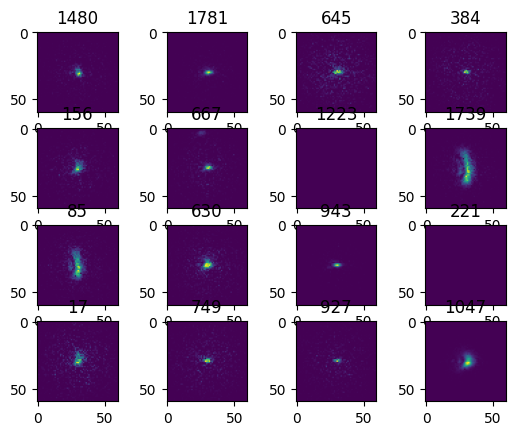

In [27]:

fig, axes = plt.subplots(4,4)

np.random.seed(15)

for i in range(16):
    thu_i = np.random.randint(train_data.shape[0])
    axes.flatten()[i].imshow(train_data[thu_i,0,...])
    axes.flatten()[i].set_title(thu_i)


In [28]:
import torch
import torch.nn as nn

class ParticleAE(nn.Module):
    def __init__(self, latent_dim=32):
        super(ParticleAE, self).__init__()
        
        # Encoder: 1x60x60 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> 16x30x30
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> 32x15x15
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 15 * 15, latent_dim)
        )
        
        # Decoder: latent_dim -> 1x60x60
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 15 * 15),
            nn.Unflatten(1, (32, 15, 15)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> 16x30x30
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # -> 1x60x60
            nn.Sigmoid() # Keeps output pixels between 0 and 1
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction, latent

In [29]:
from torch.utils.data import DataLoader, TensorDataset



# Convert to PyTorch Tensors
# Filter out the empty (zero) thumbnails first!
valid_mask = train_data.sum(axis=(1, 2, 3)) > 0
data_tensor = torch.tensor(train_data[valid_mask], dtype=torch.float32)

dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParticleAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# Loop
epochs = 50
for epoch in range(epochs):
    total_loss = 0
    for batch in loader:
        img = batch[0].to(device)
        
        # Forward
        recon, _ = model(img)
        loss = criterion(recon, img)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/len(loader):.6f}")

Epoch 0, Loss: 0.078203
Epoch 10, Loss: 0.000603
Epoch 20, Loss: 0.000408
Epoch 30, Loss: 0.000356
Epoch 40, Loss: 0.000335


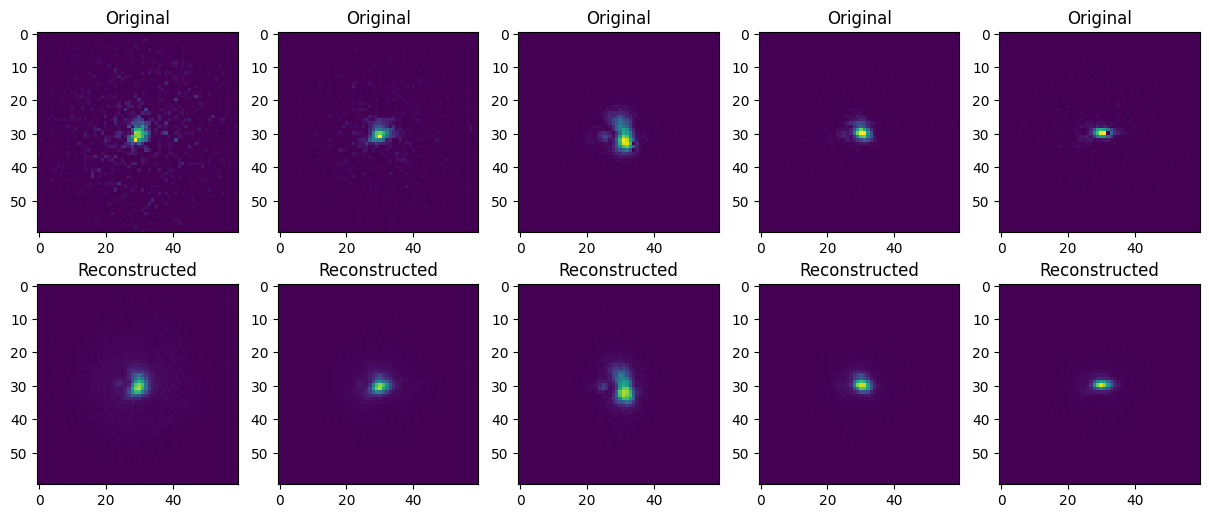

In [30]:
model.eval()
i = 250
with torch.no_grad():
    # Grab a few samples from your data_tensor
    sample_input = data_tensor[i:i+5].to(device)
    recon, _ = model(sample_input)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(sample_input[i, 0].cpu(), vmin=0, vmax=1)
    axes[0, i].set_title("Original")
    axes[1, i].imshow(recon[i, 0].cpu(), vmin=0, vmax=1)
    axes[1, i].set_title("Reconstructed")
plt.show()

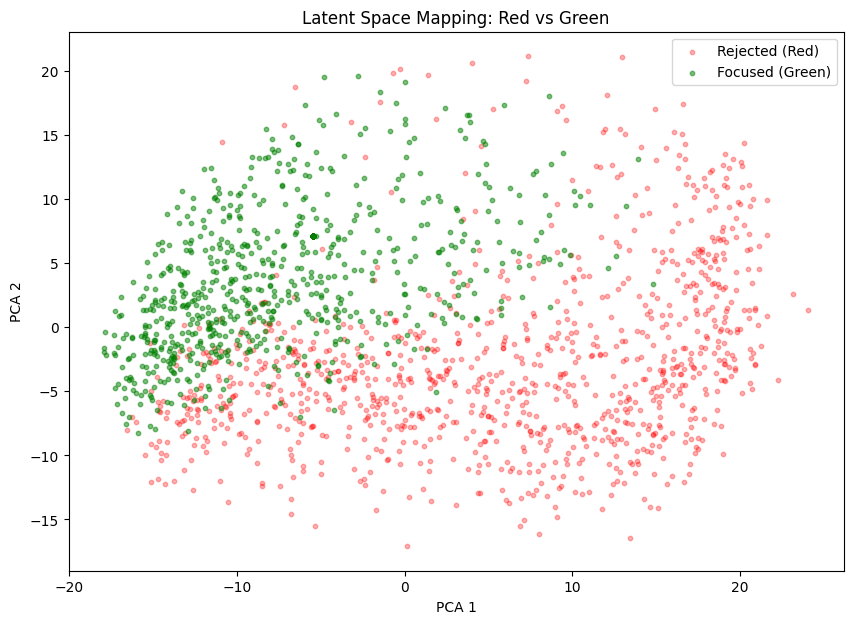

In [39]:
# 1. Process ALL your thumbnails (Red + Green)
# Replace 'thumbnails' with your original raw thumbnail array variable
all_proc = process_thumbnails(thumbnails) 

all_proc_tensor = torch.tensor(all_proc, dtype=torch.float32)

# 3. Get the Latent Vectors
model.eval()
with torch.no_grad():
    _, latent = model(all_proc_tensor.to(device))
    latent = latent.cpu().numpy()

# 4. Project to 2D
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(latent)

# 5. Plot!
plt.figure(figsize=(10, 7))
# Plot rejected (Red) peaks
plt.scatter(coords[~cbr1.filter, 0], coords[~cbr1.filter, 1], 
            c='red', label='Rejected (Red)', alpha=0.3, s=10)
# Plot focused (Green) peaks
plt.scatter(coords[cbr1.filter, 0], coords[cbr1.filter, 1], 
            c='green', label='Focused (Green)', alpha=0.5, s=10)

plt.legend()
plt.title("Latent Space Mapping: Red vs Green")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

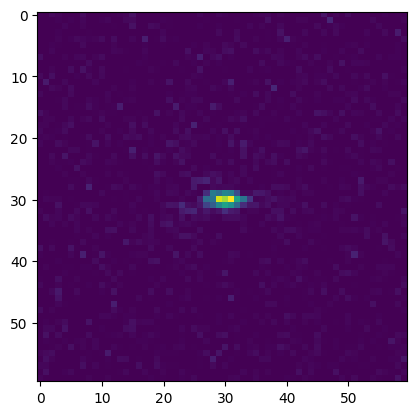

In [70]:
loc = np.where(np.logical_and(coords[:, 0]<-10, coords[:, 1]>0))
#loc = np.where(np.logical_and(coords[:, 0]>0, coords[:, 1]<0))

plt.imshow(thumbnails[np.random.choice(loc[0])])
#print(loc)

(1818, 2)


Text(0.5, 1.0, 'Most Extreme Morphology: Index 41')

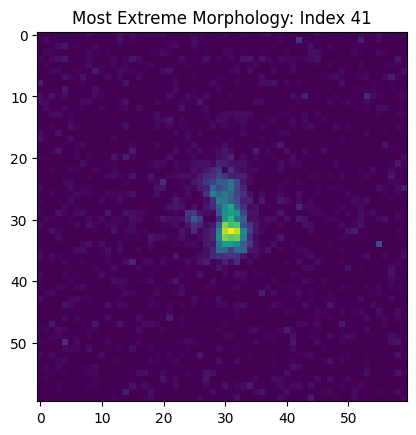

In [69]:
print(coords.shape)
# Find the index of the particle with the highest PCA 1 value
extreme_idx = np.argmin(coords[cbr1.filter, 0])

# Plot that specific thumbnail
plt.imshow(thumbnails[extreme_idx])
plt.title(f"Most Extreme Morphology: Index {extreme_idx}")